Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE" and remove every line containing the expression: "raise ..." (if you leave such a line your code will not run).

Do not remove any cell from the notebook you downloaded. You can add any number of cells (and remove them if not more necessary). 

## IMPORTANT: make sure to rerun all the code from the beginning to obtain the results for the final version of your notebook, since this is the way we will do it before evaluating your notebook!!!

## Make sure to name your notebook file (.ipynb) correctly:
### - The linear classification file: LC_NAMESURNAME_ID (E.g. : LC_MARIOROSSI_2204567)
### - The linear regression file: LR_NAMESURNAME_ID (E.g. : LR_MARIOROSSI_2204567)

## Fill in your name, surname and id number (numero matricola) below:

In [1]:
# Reproducible project seed, not a university registration number.
NAME = "Stelina Mukaj"
ID_number = 42  # Replace with your matricola only if submitting to the course.
import numpy as np
np.random.seed(ID_number)


---

# Classification on Wine Dataset

### Dataset description

We will be working with a dataset on wines from the UCI machine learning repository
(http://archive.ics.uci.edu/ml/datasets/Wine ). It contains data for 178 instances. 
The dataset is the results of a chemical analysis of wines grown in the same region
in Italy but derived from three different cultivars. The analysis determined the
quantities of 13 constituents found in each of the three types of wines. 

### The features in the dataset are:

- Alcohol
- Malic acid
- Ash
- Alcalinity of ash
- Magnesium
- Total phenols
- Flavanoids
- Nonflavanoid phenols
- Proanthocyanins
- Color intensity
- Hue
- OD280/OD315 of diluted wines
-Proline




We first import all the packages that are needed

In [2]:

import matplotlib.pyplot as plt


import numpy as np
import scipy as sp
from scipy import stats
from sklearn import datasets
from sklearn import linear_model
import copy


In [3]:
np.random.seed(ID_number)


# Perceptron
We will implement the perceptron and use it to learn a halfspace with 0-1 loss.

Load the dataset from scikit learn and then split in training set and test set (50%-50%) after applying a random permutation to the dataset.

In [4]:
# Load the dataset from scikit learn
wine = datasets.load_wine()
# Get input and output data from the dataset
X = wine.data
Y = wine.target
# Create new labels
Y = np.where(Y == 0, -1, Y)
Y = np.where(Y == 2, -1, Y)
# Let's get the number of features
d = X.shape[1]


In [5]:
##### Helper functions, do not modify them. You will need them for the first TODO
def check_constraints(labels, all_possibile_labels, min_num_istances):
    # Count the number of occurrences using numpy
    unique, counts = np.unique(labels, return_counts=True)
    if len(all_possibile_labels) != len(unique):
        return True  #there are not all the labels
    if (counts >= min_num_istances).all():
        return False #there are enough istances of each label
    else:
        return True  #there are not enough istances of each label
    
def need_new_shuffle(y_train, y_test, all_possibile_labels, min_num_istances):    #understands if the training and test are ok  
    return (check_constraints(y_train, all_possibile_labels, min_num_istances) or #train set not ok 
            check_constraints(y_test, all_possibile_labels, min_num_istances))    #test set not ok


In [6]:
def create_train_val_test_datasets(features, labels, m_t, m_test):
    features, labels = np.asarray(features), np.asarray(labels)
    if len(features) != len(labels) or m_t + m_test != len(labels) or min(m_t,m_test)<0:
        raise ValueError("Invalid split sizes")
    idx = np.random.permutation(len(labels))
    return features[idx[:m_t]], labels[idx[:m_t]], features[idx[m_t:]], labels[idx[m_t:]]

def create_train_val_test_datasets_with_constraints(features, labels, m_t, m_test, min_num_istances):
    classes, counts = np.unique(labels, return_counts=True)
    if min_num_istances < 0 or np.any(counts < 2*min_num_istances) or min(m_t,m_test) < len(classes)*min_num_istances:
        raise ValueError("Class-count constraints are impossible")
    for _ in range(10000):
        splits = create_train_val_test_datasets(features, labels, m_t, m_test)
        if not need_new_shuffle(splits[1], splits[3], classes, min_num_istances):
            return splits
    # Construct a feasible split if random rejection sampling is unlikely.
    labels = np.asarray(labels)
    reserved_train, reserved_test, remaining = [], [], []
    for label in classes:
        ids = np.random.permutation(np.flatnonzero(labels == label))
        reserved_train.extend(ids[:min_num_istances])
        reserved_test.extend(ids[min_num_istances:2*min_num_istances])
        remaining.extend(ids[2*min_num_istances:])
    remaining = np.random.permutation(remaining)
    needed = m_t-len(reserved_train)
    tr = np.random.permutation(np.r_[reserved_train, remaining[:needed]]).astype(int)
    te = np.random.permutation(np.r_[reserved_test, remaining[needed:]]).astype(int)
    return np.asarray(features)[tr], labels[tr], np.asarray(features)[te], labels[te]

m_t = 80
x_train, y_train, x_test, y_test = create_train_val_test_datasets_with_constraints(X,Y,m_t,len(Y)-m_t,25)


In [7]:
assert x_train.shape == (m_t,       x_train.shape[1]) # here we are comparing two tuples (it is an element wise comparison)
assert x_test.shape  == (len(Y)-m_t, x_test.shape[1])


In [8]:
# Let's add a 1 in front of each sample so that we can use a vector to describe all the coefficients of the model.
# Do not run this cell multiple times otherwise you will continue adding ones... 
# (we add the assert to avoid such issue)

assert x_train.shape[1] == d
assert x_test.shape[1] == d 

x_train = np.hstack((np.ones((x_train.shape[0],1)), x_train))
x_test  = np.hstack((np.ones((x_test.shape[0],1)),  x_test))


**TO DO 2** Now complete the function *perceptron*. Since the perceptron does not terminate if the data is not linearly separable, your implementation should return the desired output (see below) if it reached the termination condition seen in class or if a maximum number of iterations have already been run, where 1 iteration corresponds to 1 update of the perceptron weights. If the perceptron returns because the maximum number of iterations has been reached, you should return an appropriate model (the best seen along the iterations). 

The input parameters to pass are:
- $X$: the matrix of input features, one row for each sample
- $Y$: the vector of labels for the input features matrix X
- $max\_num\_iterations$: the maximum number of iterations for running the perceptron

The output values are:
- $best\_w$: the vector with the coefficients of the best model.
- $best\_error$: the fraction of missclassified samples for the best model. (# missclassified/# possible errors)

- $w\_iters$: a list of the every coefficients found by the algorithm. This is an 'auxiliary output' (it is not needed for the actual algorithm) that will allows us to have a better insight on the algorithm's behaviour.
- $error\_iters$: a list of the fraction of missclassified samples for every model found. (Again an auxiliary output).

- $w\_bestIters$: a list of the current best coefficients selected by the algorithm (Again an auxiliary output) 
- $error\_bestIters$: a list of the fraction of missclassified samples for current best model. (Again an auxiliary output).

Note that $w\_iters$, $error\_iters$, $w\_bestIters$ and $error\_bestIters$ must be of the same length.

**Auxiliary functions**

In order to correclty complete the perceptron function it is warmly recommended to define some auxiliary functions ("*find_missclassified*" and "*choose_missclassified*"). 


"__find_missclassified__"
This function looks for missclassified data points in the dataset $X$.

The input parameters to pass are:
- $X$: the matrix of input features, one row for each sample
- $Y$: the vector of labels for the input features matrix X
- $curr\_w$: the current value of the parameter vector *w*

The output value is:
- $missclassified\_indeces$: a numpy array cointaining all the missclassified indeces  


"__choose_missclassified__"
This function return one single index choosen from a array of indeces. If the array is empty it returns a non valid index: -1. 

The input parameters to pass are:
- $missclassified\_indeces$: numpy array containing missclassified indeces

The output value is:
- $index$: Integer (or np.int64) containing the choosen index


In [9]:
def find_missclassified(X, Y, curr_w):
    # Points on the boundary count as mistakes, consistently with sign(0)=0.
    return np.flatnonzero(np.asarray(Y).ravel() * (X @ curr_w) <= 0)

def choose_missclassified(missclassified_indeces):
    return int(np.random.choice(missclassified_indeces)) if len(missclassified_indeces) else -1

def perceptron(X, Y, max_num_iterations):
    Y = np.asarray(Y).ravel()
    curr_w = np.zeros(X.shape[1])
    best_w = curr_w.copy()
    mistakes = find_missclassified(X, Y, curr_w)
    best_error = len(mistakes)/len(Y)
    w_iters, error_iters, w_bestIters, error_bestIters = [], [], [], []
    for _ in range(max_num_iterations):
        if not len(mistakes):
            break
        index = choose_missclassified(mistakes)
        curr_w += Y[index] * X[index]
        mistakes = find_missclassified(X,Y,curr_w)
        error = len(mistakes)/len(Y)
        if error < best_error:
            best_w, best_error = curr_w.copy(), error
        w_iters.append(curr_w.copy())
        error_iters.append(error)
        w_bestIters.append(best_w.copy())
        error_bestIters.append(best_error)
    return best_w, best_error, w_bestIters, error_bestIters, w_iters, error_iters


In [10]:
index = choose_missclassified(np.array(list(range(100))))
assert type(index) == np.int64 or type(index) == int or type(index) == np.int32


In [11]:
# Now run the perceptron for 100 iterations
# We want just to see the output of the algorithm, so we can avoid assigning the auxiliary outputs to actual variables
w_found, training_error, _, _, _,_ = perceptron(x_train, y_train, 100)
print("Training error with 100 iterations: " + str(training_error))


Training error with 100 iterations: 0.2


In [12]:
def classification_loss(y_target, predictions):
    y, pred = np.asarray(y_target).ravel(), np.asarray(predictions).ravel()
    if y.shape != pred.shape or not len(y):
        raise ValueError("Nonempty matching arrays are required")
    return float(np.mean(y != pred))

def compute_fraction_missclassified(X,Y,w):
    return classification_loss(Y,np.sign(X @ w))


In [13]:
assert classification_loss(np.array([[1],[3]]), np.array([[1],[3]])) == 0
assert classification_loss(np.array([[1],[2]]), np.array([[1],[3]])) == 0.5
y_labels, y_predictions = np.random.choice(10, 1000000), np.random.choice(10, 1000000)
assert np.isclose(classification_loss(y_labels, y_predictions), 0.9, atol=0.01)
assert training_error == compute_fraction_missclassified(x_train, y_train, w_found)


In [14]:
# now run the perceptron for 10000 iterations
w_found, training_error,w_listBest,error_list_trainBest,w_list, error_list_train = perceptron(x_train, y_train, 10000)
print(f"Training Error for 10000 iterations is {compute_fraction_missclassified(x_train, y_train, w_found):.4f}")
print(f"Test Error for 10000 iterations is {compute_fraction_missclassified(x_test, y_test, w_found):.4f}")


Training Error for 10000 iterations is 0.1625
Test Error for 10000 iterations is 0.2449


**TO DO 4**: We want to have a better understanding of the hidden behaviour of perceptron algorithm. We indeed defined four auxiliary outputs that should allow us to inspect the training process in more depth. In particular, we want to check if the sequence of models' errors found through the different iterations is characterized by a decreasing trend, with respect to both training and test datasets.

The function `perceptron` already returns the sequence of errors, which is ready to be plotted. However, the errors for the test set aren not immediately available: we nonetheless have all different models, thus we can easily compute them! 

In [15]:
def error_models(X,Y,w_l):
    return [compute_fraction_missclassified(X,Y,w) for w in w_l]


In [16]:
assert len(error_models(x_test, y_test, w_list)) == len(error_list_train)
assert len(error_models(x_test, y_test, w_listBest)) == len(error_list_trainBest)
assert len(error_models(x_test, y_test, w_list)) <= 10000
assert len(error_models(x_test, y_test, w_listBest)) <= 10000


Text(0.5, 1.0, 'Test Error using the w found at the current iteration')

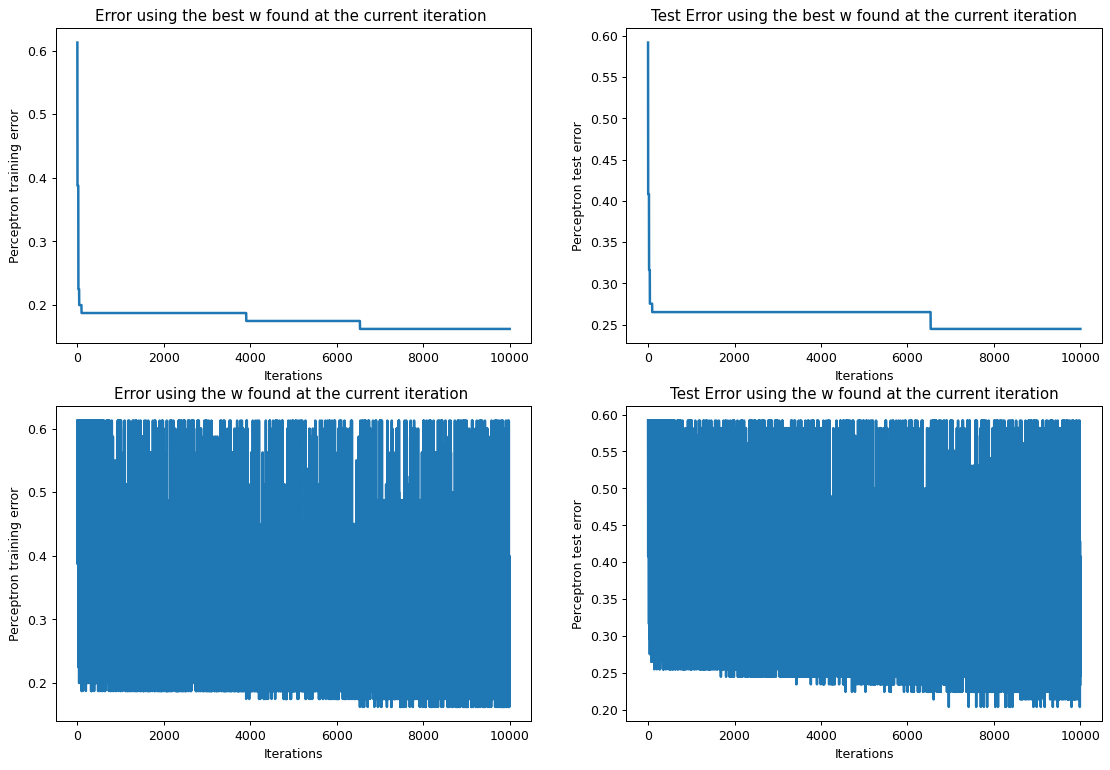

In [17]:
error_list_testBest = error_models(x_test, y_test, w_listBest)
error_list_test = error_models(x_test, y_test, w_list)
fig, axes = plt.subplots(2,2, figsize=(15,10))
axes[0][0].plot([i for i in range(len(w_listBest))], error_list_trainBest, linewidth=2)
axes[0][0].set_xlabel('Iterations')
axes[0][0].set_ylabel('Perceptron training error')
axes[0][0].set_title('Error using the best w found at the current iteration ')
axes[0][1].plot([i for i in range(len(w_list))], error_list_testBest, linewidth=2)
axes[0][1].set_xlabel('Iterations')
axes[0][1].set_ylabel('Perceptron test error')
axes[0][1].set_title('Test Error using the best w found at the current iteration')
axes[1][0].plot([i for i in range(len(w_list))], error_list_train, linewidth=2)
axes[1][0].set_xlabel('Iterations')
axes[1][0].set_ylabel('Perceptron training error')
axes[1][0].set_title('Error using the w found at the current iteration ')
axes[1][1].plot([i for i in range(len(w_list))], error_list_test, linewidth=2)
axes[1][1].set_xlabel('Iterations')
axes[1][1].set_ylabel('Perceptron test error')
axes[1][1].set_title('Test Error using the w found at the current iteration')


**TO DO 5**: Answer in the next cell:

Consider the plots above. How do the errors compare? Can you identify a some particular property? 

The pocket training error is nonincreasing by construction, while the current iterate's error can oscillate. Neither test trajectory has a monotonicity guarantee because test labels do not guide updates or selection. With seed 42, the 10,000-update pocket has 16.25% training error and 24.49% test error. The later zero-error logistic fit shows that this binary training split is separable; the raw, differently scaled wine features can make perceptron convergence slow. A finite update cap can therefore stop before a separator is found.

# Logistic Regression
Now we use logistic regression, as implemented in Scikit-learn, to predict labels. We first do it for 2 labels and then for 3 labels. We will also plot the decision region of logistic regression.

We first load the dataset again.

In [18]:
import random
# Let's reinitialize the random seed 
random.seed(ID_number)
np.random.seed(ID_number)

# In the following we will keep the dataset with only two classes (which we aggregated before)
m_t = 80
x_train, y_train, x_test, y_test = create_train_val_test_datasets_with_constraints(X, Y, m_t, len(Y)-m_t, 25)


To define a logistic regression model in Scikit-learn use the instruction

$linear\_model.LogisticRegression(C=1e5, max\_iter=?)$

$C$ is a parameter related to *regularization*, a technique that
we will see later in the course. Setting it to a high value is almost
as ignoring regularization, so the instruction above corresponds to the
logistic regression you have seen in class. Choose the proper number of iterations: max_iter.

To learn the model you need to use the $fit(...)$ instruction and to predict you need to use the $predict(...)$ function. See the Scikit-learn documentation for how to use it (have a look at the logreg.score method too).

**TO DO** Define the logistic regression model, then learn the model using the training set and predict on the test set. Then print the fraction of samples missclassified in the training set and in the test set.

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
max_iter = 10000
# Fit scaling on training data only; predict still accepts raw features.
logreg = make_pipeline(StandardScaler(), linear_model.LogisticRegression(C=1e5, max_iter=max_iter, random_state=ID_number))
logreg.fit(x_train,y_train)
error_rate_training = classification_loss(y_train,logreg.predict(x_train))
error_rate_test = classification_loss(y_test,logreg.predict(x_test))
error_rate_test_sklearn = 1-logreg.score(x_test,y_test)
print("Training error:",error_rate_training,"Test error:",error_rate_test)


Training error: 0.0 Test error: 0.061224489795918366


In [20]:
assert np.isclose(error_rate_test, error_rate_test_sklearn)


Now we do logistic regression for classification with 3 classes.

In [21]:
random.seed(ID_number)
np.random.seed(ID_number)

X = wine.data
Y = wine.target

m_t = 80
x_train, y_train, x_test, y_test = create_train_val_test_datasets_with_constraints(X, Y, m_t, len(Y)-m_t, 20)

_, counts = np.unique(y_train, return_counts=True)
assert (counts >= 20).all()
_, counts = np.unique(y_test, return_counts=True)
assert (counts >= 20).all()


In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
max_iter = 10000
# Fit scaling on training data only; predict still accepts raw features.
logreg = make_pipeline(StandardScaler(), linear_model.LogisticRegression(C=1e5, max_iter=max_iter, random_state=ID_number))
logreg.fit(x_train,y_train)
error_rate_training = classification_loss(y_train,logreg.predict(x_train))
error_rate_test = classification_loss(y_test,logreg.predict(x_test))
error_rate_test_sklearn = 1-logreg.score(x_test,y_test)
print("Training error:",error_rate_training,"Test error:",error_rate_test)


Training error: 0.0 Test error: 0.061224489795918366


In [23]:
assert np.isclose(error_rate_test, error_rate_test_sklearn)


**TO DO 8**: Answer in the next cell:

-If you get a zero training error using the logistic regression, what can you say about data separbility?

-In such case the perseptron would be able to stop even without a number of maximum iterations? If yes, could we find an upperbound for the number of iterations requiered by the perceptron in order to stop?

Both fitted logistic models attain zero training classification error in this run. For the binary model, this exhibits a separating affine hyperplane; with strict positive margin $\gamma$, augmented input norm at most $R$, and initialization at zero, the perceptron mistake bound is $(R/\gamma)^2$. Thus it eventually terminates even without an update cap, although that bound may greatly exceed 10,000 on unscaled features. For the three-class model, zero error exhibits separation by competing linear scores; applying a binary perceptron directly to three labels is invalid and requires a multiclass extension and margin assumption. None of these training facts guarantees zero test error: both logistic experiments here have 6.12% test error.

We now are going to plot prediction boundaries of a logistic regression model, in order to plot them we need to reduce the number of features to 2: pick two features and restrict the dataset to include only two features, whose indices are specified in the $feature$ vector below. Then split into training and test.

In [24]:
# TODO 9
#to make the plot we need to reduce the data to 2D, so we choose two features
features_list = ['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids',
                 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                 'Proline']
labels_list = ['class_0', 'class_1', 'class_2']

index_feature1 = 0  # You can choose the feature you prefer here
index_feature2 = 1  # You can choose the feature you prefer here
features = [index_feature1, index_feature2]

feature_name0 = features_list[features[0]]
feature_name1 = features_list[features[1]]

X = X[:,features]

# In the following we will keep the dataset with 3 classes
m_t = 80
x_train, y_train, x_test, y_test = create_train_val_test_datasets_with_constraints(X, Y, m_t, len(Y)-m_t, 20)

# Fit a model on the reduced set of fetures
logreg = make_pipeline(StandardScaler(), linear_model.LogisticRegression(C=1e5, max_iter=10000, random_state=ID_number))
logreg.fit(x_train,y_train)
print("Two-feature training error:", classification_loss(y_train, logreg.predict(x_train)))
print("Two-feature test error:", classification_loss(y_test, logreg.predict(x_test)))


Two-feature training error: 0.15
Two-feature test error: 0.2653061224489796


In [25]:
assert logreg.predict(x_test).shape == (x_test.shape[0], )


The code below uses the model in $logreg$ to plot the decision region for the two features chosen above, with colors denoting the predicted value. It also plots the points (with correct labels) in the training set. It makes a similar plot for the test set.

Text(0.5, 1.0, 'Test set')

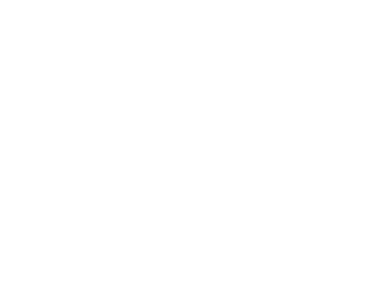

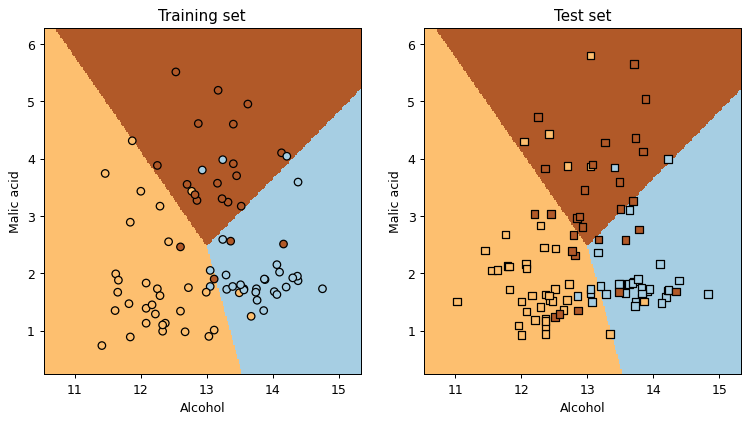

In [26]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)

plt.figure(1, figsize=(4, 3))
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
axes[0].scatter(x_train[:, 0], x_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Paired)
axes[0].set_xlabel(feature_name0)
axes[0].set_ylabel(feature_name1)

axes[0].set_xlim(xx.min(), xx.max())
axes[0].set_ylim(yy.min(), yy.max())
axes[0].set_title('Training set')

# Put the result into a color plot
Z = Z.reshape(xx.shape)
axes[1].pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the test points 
axes[1].scatter(x_test[:, 0], x_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.Paired, marker='s')
axes[1].set_xlabel(feature_name0)
axes[1].set_ylabel(feature_name1)

axes[1].set_xlim(xx.min(), xx.max())
axes[1].set_ylim(yy.min(), yy.max())
axes[1].set_title('Test set')


**TO DO 10**: Answer in the next cell (you do not need more than 5-7 lines):

1- What is the shape of the decision boundaries in the higher dimensional space ($\mathbb{R}^d$)? Why?

2- In this lower dimensional space, are the features linearily separable? What if you consider the entire feature vector (without any dimensionality reduction)?  


Pairwise logistic boundaries satisfy $(w_i-w_j)^Tx+(b_i-b_j)=0$: hyperplanes in $\mathbb{R}^d$, lines with two features, and multiclass regions formed by intersecting half-spaces. Alcohol and malic acid produce 15.00% training and 26.53% test error in this run, with overlapping classes in the plot; one imperfect fit alone is not a proof of nonseparability. All 13 features yield a zero-error training classifier and 6.12% test error, demonstrating that the full feature representation permits separation by the fitted linear scores.